In [12]:
import os
import rasterio as rio
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.path as mpth
from pathlib import Path

import Functions
import importlib

importlib.reload(Functions)

output_folder = Path('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents')
app_path = Functions.get_input_path() / 'App'
input_path = app_path / 'Documents' / 'csv'

path: /home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA


In [13]:
sigma_TM = pd.DataFrame(pd.read_csv(input_path / 'TimeSeries_sigma.csv'))
sigma_TM['Date'] = pd.to_datetime(sigma_TM['Date'])
sigma_TM.drop(sigma_TM[sigma_TM['mean'] == 0].index,inplace=True)

sigma_TM = sigma_TM.sort_values(by=['Code', 'Band', 'Date'])

display(sigma_TM)

,Code,Date_Band,mean,std,Date,Band,Name,Type
1298,1545384,20170104_VH,-15.490180,1.038437,2017-01-04,VH,DB_SB2_C,Potatoes
1300,1545384,20170110_VH,-14.146261,1.136036,2017-01-10,VH,DB_SB2_C,Potatoes
1302,1545384,20170116_VH,-20.622658,0.922879,2017-01-16,VH,DB_SB2_C,Potatoes
1304,1545384,20170122_VH,-22.050701,0.694627,2017-01-22,VH,DB_SB2_C,Potatoes
1306,1545384,20170128_VH,-16.818918,0.731224,2017-01-28,VH,DB_SB2_C,Potatoes
...,...,...,...,...,...,...,...,...
935,2278835,20171206_VV,-6.205426,0.920910,2017-12-06,VV,PVD-M-C,Corn
937,2278835,20171212_VV,-11.775089,0.645342,2017-12-12,VV,PVD-M-C,Corn
939,2278835,20171218_VV,-5.921874,1.043583,2017-12-18,VV,PVD-M-C,Corn
941,2278835,20171224_VV,-6.724238,1.070252,2017-12-24,VV,PVD-M-C,Corn


In [19]:
phen = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Averaged_Phenology_Stage.csv')
df_long = phen.melt(
    id_vars="Code",        # la colonna che resta fissa
    var_name="Date",       # nuova colonna con i nomi delle vecchie colonne (le date)
    value_name="Phen"      # nuova colonna con i valori
)
df_long["Date"] = pd.to_datetime(df_long["Date"], format="%Y-%m-%d %H:%M:%S").dt.normalize()
df_long.dropna(subset='Phen', inplace=True)
display(df_long[df_long['Code'] == 1553694])
phen_PCHIP = []

for c in df_long['Code'].unique():

    df = df_long[df_long['Code'] == c].copy()
    df = df.set_index('Date')                    # <-- Date diventa l'indice
    df = df.sort_index()                         # utile per l'interpolazione temporale

    raggio_date_giornaliero = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
    df = df.reindex(raggio_date_giornaliero)
    df.reset_index(names='Date', inplace=True)   # ora 'Date' non esiste più come colonna: nessun conflitto
    df['Code'] = c
    n_punti = df['Phen'].notna().sum()

    if n_punti >= 2:
        df['Phen_PCHIP'] = df['Phen'].interpolate(method='pchip')
    else:
        # troppo pochi punti: niente interpolazione, si tiene il valore osservato
        df['Phen_PCHIP'] = df['Phen']
        print(f"Code {c}: solo {n_punti} punto/i osservato/i, PCHIP saltata")
#Piecewise Cubic Hermite Interpolating Polynomial (PCHIP)

    phen_PCHIP.append(df)

phen_generale = pd.concat(phen_PCHIP, ignore_index=True)

phen_generale = phen_generale[['Date', 'Code', 'Phen', 'Phen_PCHIP']]
phen_generale.sort_values(by=['Code', 'Date'], inplace=True, ignore_index=True)
display(phen_generale[phen_generale['Code'] == 1553694])



,Code,Date,Phen
121,1553694,2017-06-21,18.0
145,1553694,2017-06-27,31.5
169,1553694,2017-07-03,49.0
217,1553694,2017-07-13,44.0


Code 1697691: solo 1 punto/i osservato/i, PCHIP saltata
Code 1889479: solo 1 punto/i osservato/i, PCHIP saltata
Code 1889482: solo 1 punto/i osservato/i, PCHIP saltata
Code 2294423: solo 1 punto/i osservato/i, PCHIP saltata
Code 1631664: solo 1 punto/i osservato/i, PCHIP saltata


,Date,Code,Phen,Phen_PCHIP
27,2017-06-21,1553694,18.0,18.000000
28,2017-06-22,1553694,NaN,19.978196
29,2017-06-23,1553694,NaN,22.074671
30,2017-06-24,1553694,NaN,24.282258
31,2017-06-25,1553694,NaN,26.593787
32,2017-06-26,1553694,NaN,29.002091
33,2017-06-27,1553694,31.5,31.500000
34,2017-06-28,1553694,NaN,34.560409
35,2017-06-29,1553694,NaN,38.295102
36,2017-06-30,1553694,NaN,42.155242


sigma_TM = pd.merge(
    sigma_TM, 
    phen_generale, 
    on=['Code', 'Date'], 
    how='right' 
).dropna(subset='mean')
display(sigma_TM[(sigma_TM['Code'] == 1936135) & (sigma_TM['Band'] == 'VV')])
sigma_TM.dropna(subset='Phen_PCHIP',inplace=True)
display(sigma_TM[(sigma_TM['Code'] == 1936135) & (sigma_TM['Band'] == 'VH')])


display(sigma_TM[(sigma_TM['Code'] == 2081887) & (sigma_TM['Band'] == 'VH')])

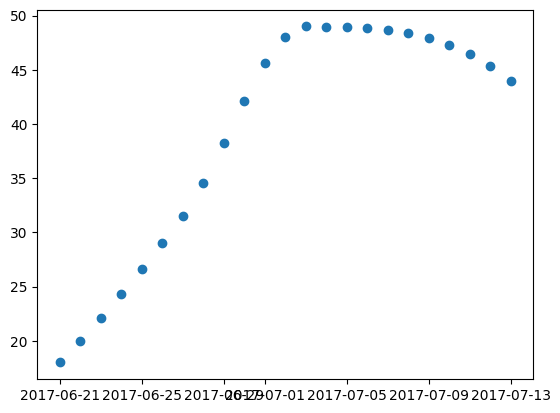

In [20]:
plt.scatter(phen_generale[phen_generale['Code'] == 1553694]['Date'], phen_generale[phen_generale['Code'] == 1553694]['Phen_PCHIP'])

In [23]:
phen_generale.to_csv('phen_generale.csv', index=None,sep=';', decimal='.')

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages



results_regression = []

output_folder.mkdir(parents=True, exist_ok=True)

pdf_filename = output_folder / 'Regression_Moisture_xField.pdf'


with PdfPages(pdf_filename) as pdf:

    for i, (_, row) in enumerate(df_statistiche_VV.iterrows()):

        codice = row['Code']
        banda = row['Band']
        tipo = row['Type']
        
        dati_gruppo = sigma_TM[(sigma_TM['Code'] == codice) & (sigma_TM['Band'] == banda)].sort_values('Date')
        
        x_in_situ = dati_gruppo['Umidita_PCHIP_%'].values
        y_calcolata = dati_gruppo['SSM_retrieved'].values
        date_asse = dati_gruppo['Date'].values

        min_date = dati_gruppo['Date'].min()
        max_date = dati_gruppo['Date'].max()
        rain_filtered = df_rainfall[(df_rainfall.index >= min_date) & (df_rainfall.index <= max_date)].reset_index()
        if len(x_in_situ) > 2:
            
            # OUTLIER SEARCH
            y_pred_grezza = row['Slope'] * x_in_situ + row['Intercept']
            residui = y_calcolata - y_pred_grezza
            
            # THRESHOLD
            soglia = 3 * row['RMSRE']
            
            mask_outlier = np.abs(residui) > soglia
            mask_inlier = np.abs(residui) <= soglia
            n_outliers = np.sum(mask_outlier)
            
            x_puliti = x_in_situ[mask_inlier]
            y_puliti = y_calcolata[mask_inlier]
            
            if len(x_puliti) > 2:
                
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
                
                # REGRSSION W/ OUTLIER
                slope_f, intercept_f, r_f, p_f, std_err = stats.linregress(x_puliti, y_puliti)
                r2_pulito = r_f ** 2

                residui = y_puliti - x_puliti
                
                rmsre_f = np.sqrt(np.mean(residui ** 2))

                results_regression.append({
                    'Code': codice,
                    'Band': banda,
                    'Type': tipo,
                    'N_points': len(x_puliti),
                    'R_Pearson': r_f,
                    'R_2': r2_pulito,
                    'P_value': p_f,
                    'Slope': slope_f,
                    'Intercept': intercept_f,
                    'RMSRE': rmsre_f
                })

                # =================================================================
                # SUBPLOT 1: SCATTER PLOT & REGRESSIONE (ax1)
                # =================================================================
                
                # 1. Disegniamo i punti validi (Blue/Teal)
                
                sns.scatterplot(x=x_puliti, y=y_puliti, 
                                color='#1f77b4', s=60, label='Valid Data', alpha=0.8, ax=ax1)
                
                # 2. Disegniamo gli outlier rimossi (Rosso con 'X')
                if n_outliers > 0:
                    sns.scatterplot(x=x_in_situ[mask_outlier], y=y_calcolata[mask_outlier], 
                                    marker='x', color="#ca4828", s=60, label='Outliers', alpha=0.8, ax=ax1)
                
                # 3. Disegniamo la retta di regressione PULITA
                x_linea = np.linspace(x_puliti.min(), x_puliti.max(), 100)
                y_linea = slope_f * x_linea + intercept_f

                sns.lineplot(x=x_linea, y=y_linea, color="#ca4828", 
                             label=f'Cleaned Fit\n$R^2$ without outlier = {r2_pulito:.3f}', alpha=0.8, ax=ax1)
                


                ax1.fill_between(x_linea, 
                                 y_linea - std_err, 
                                 y_linea + std_err, 
                                 color="#ca4828", alpha=0.15, label='1 Std. Dev.')

                # Linea di riferimento ideale 1:1
                limiti = [min(x_in_situ.min(), y_calcolata.min()), max(x_in_situ.max(), y_calcolata.max())]
                ax1.plot(limiti, limiti, color='gray', linestyle=':', alpha=0.5, label='Ideal 1:1')
                
                # Formattazione pannello 1
                ax1.set_title(f"{codice} - {banda} - {tipo}\n($R^2$ raw: {row['R_2']:.3f})",
                              fontsize=11, fontweight='bold')
                ax1.set_xlabel("SSM In Situ ($m^3/m^3$)", fontsize=10)
                ax1.set_ylabel("SSM Retr ($m^3/m^3$)", fontsize=10)
                ax1.legend(loc='upper left', fontsize=9)
                ax1.grid(True, linestyle='--', alpha=0.5)

                # =================================================================
                # SUBPLOT 2: ANDAMENTO TEMPORALE (ax2)
                # =================================================================
                
                dati_gruppo = sigma_TM_copy[(sigma_TM_copy['Code'] == codice) & (sigma_TM_copy['Band'] == banda)].sort_values('Date')

                x_in_situ = dati_gruppo['Umidita_PCHIP_%'].values
                y_calcolata = dati_gruppo['SSM_retrieved'].values
                date_asse = dati_gruppo['Date'].values

                mask_uguali = (x_in_situ == y_calcolata)
                
                # Se c'è almeno un punto in cui coincidono, disegniamo le X rosse
                if np.any(mask_uguali):
                    ax2.scatter(date_asse[mask_uguali], y_calcolata[mask_uguali], 
                                marker='x', color="red", s=90, linewidth=2, zorder=6, label='Tie-Point')


                # Grafico linea + marker per l'umidità In Situ (usiamo il verde per distinguerlo bene)
                sns.lineplot(x=date_asse, y=x_in_situ, color='#2ca02c', marker='o', 
                             linewidth=1.8, label='SSM In Situ', ax=ax2)
                
                # Grafico linea + marker per l'umidità Stimata (riprendiamo il blu dei dati validi dello scatter)
                sns.lineplot(x=date_asse, y=y_calcolata, color='#1f77b4', marker='^', linestyle='--',
                             linewidth=1.5, label='SSM Retrieved', ax=ax2)
                
                # Opzionale ma consigliato: marchiamo con una 'X' rossa gli outlier anche sulla linea temporale della stima
                if n_outliers > 0:
                    ax2.scatter(date_asse[mask_outlier], y_calcolata[mask_outlier], 
                                marker='x', color="#ca4828", s=70, zorder=5, label='Outliers Identified')
                ax3 = ax2.twinx()

                # Usa il bar plot nativo di Matplotlib invece di Seaborn
                ax3.bar(rain_filtered['date'], rain_filtered['prec_mm'], color='blue', alpha=0.2, width=0.4) 
                # Nota: puoi regolare 'width' (es. 0.5 o 1.0) in base a quanto vuoi spesse le barre

                ax3.set_ylabel('Rain (mm)', color='blue', fontsize=12)
                ax3.tick_params(axis='y', labelcolor='blue')


                # Formattazione pannello 2
                ax2.set_title("Time Series Humidity", fontsize=11, fontweight='bold')
                ax2.set_xlabel("Date", fontsize=10)
                ax2.set_ylabel("SSM ($m^3/m^3$)", fontsize=10)
                ax2.legend(loc='upper right', fontsize=9)
                ax2.grid(True, linestyle='--', alpha=0.5)
                
                # Ruotiamo le date sull'asse X per non farle sovrapporre
                ax2.tick_params(axis='x', rotation=30)
                
                # Compattiamo il layout globale prima del salvataggio
                plt.tight_layout()
                
                # Salva la figura a due pannelli nella pagina corrente del PDF
                pdf.savefig()
                plt.close()

KeyError: 'Umidita_PCHIP_%'